<a href="https://colab.research.google.com/github/Christimaria/Flight_Price_Prediction/blob/main/Flight_Ticket_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [13]:
df=pd.read_csv("/content/airlines_flights_data.csv", on_bad_lines='skip')
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
df.shape

(300153, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [16]:
df.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [17]:
# Remove rows with missing values
df.dropna(inplace=True)

# Verify
df.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [18]:
df.shape

(300153, 12)

In [19]:
df.drop("index", axis=1, inplace=True)

In [20]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [21]:
# Separate categorical and numerical columns

categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

Numerical Columns:
Index(['duration', 'days_left', 'price'], dtype='object')






```
#
```

With Label Encoding the model thinks:Air India < IndiGo < Vistara

With One-Hot Encoding, it becomes: every airline is treated equally.

In [22]:
# Applying One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Display first five rows
df_encoded.head()

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,flight_6.00E-102,flight_6.00E-105,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,2.33,1,5953,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,2.17,1,5956,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,2.25,1,5955,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
4,2.33,1,5955,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True


In [23]:
print(df_encoded.shape)

(300153, 1591)


In [24]:
df_encoded.head()

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,flight_6.00E-102,flight_6.00E-105,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,2.33,1,5953,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,2.17,1,5956,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,2.25,1,5955,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
4,2.33,1,5955,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True


In [25]:
# Features and Target

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print(X.shape)
print(y.shape)

(300153, 1590)
(300153,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (240122, 1590)
Testing : (60031, 1590)


First Model (Linear Regression)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr = LinearRegression()

In [29]:
lr.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [32]:
r2 = r2_score(y_test, y_pred_lr)

mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

In [33]:
print("R² :", round(r2,4))
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))

R² : 0.9255
MAE : 4253.95
MSE : 38405297.73
RMSE: 6197.2


In [34]:
results = pd.DataFrame({
    "Model":["Linear Regression"],
    "R²":[r2],
    "MAE":[mae],
    "RMSE":[rmse]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.925496,4253.954027,6197.200798


Second model (Decision Tree Regression)

In [35]:
from sklearn.tree import DecisionTreeRegressor

In [36]:
dt = DecisionTreeRegressor(
    random_state=42
)

In [37]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [38]:
y_pred_dt = dt.predict(X_test)

In [39]:
dt_r2 = r2_score(y_test, y_pred_dt)

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Results")
print("---------------------")
print("R² :", round(dt_r2,4))
print("MAE :", round(dt_mae,2))
print("RMSE:", round(dt_rmse,2))

Decision Tree Results
---------------------
R² : 0.9824
MAE : 885.73
RMSE: 3014.8


In [40]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression","Decision Tree"
    ],
    "R²": [
        r2,
        dt_r2
    ],
    "MAE": [
        mae,
        dt_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse
    ]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.925496,4253.954027,6197.200798
1,Decision Tree,0.982368,885.729612,3014.797061


Third model(Random Forest Regression)

In [41]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [44]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [45]:
y_pred_rf = rf.predict(X_test)

In [46]:
rf_r2 = r2_score(y_test, y_pred_rf)

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("---------------------")
print("R² :", round(rf_r2,4))
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))

Random Forest Results
---------------------
R² : 0.9889
MAE : 865.39
RMSE: 2391.91


In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R²": [
        r2,
        dt_r2,
        rf_r2
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ]
})

results.sort_values(by="R²", ascending=False)

,Model,R²,MAE,RMSE
2,Random Forest,0.988901,865.391960,2391.906946
1,Decision Tree,0.982368,885.729612,3014.797061
0,Linear Regression,0.925496,4253.954027,6197.200798


## Model Comparison Insight

Three regression models were evaluated for flight ticket price prediction. Random Forest achieved the highest performance with an R² score of **0.9889**, making it the most accurate model. Decision Tree also performed exceptionally well with an R² score of **0.9823**, while Linear Regression achieved **0.9255**. The superior performance of the tree-based models indicates that flight ticket prices are influenced by complex, non-linear relationships that are better captured by ensemble learning techniques.

In [48]:
# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
1589,class_Economy,0.879552
0,duration,0.048211
1,days_left,0.017858
2,airline_Air_India,0.006355
6,airline_Vistara,0.003937
1585,destination_city_Delhi,0.003862
1568,source_city_Delhi,0.003320
1571,source_city_Mumbai,0.002080
1588,destination_city_Mumbai,0.001957
1587,destination_city_Kolkata,0.001853


## Feature Importance Analysis

Feature importance helps identify which input variables contribute the most to the Random Forest model's predictions. Higher importance scores indicate a greater influence on predicting flight ticket prices.

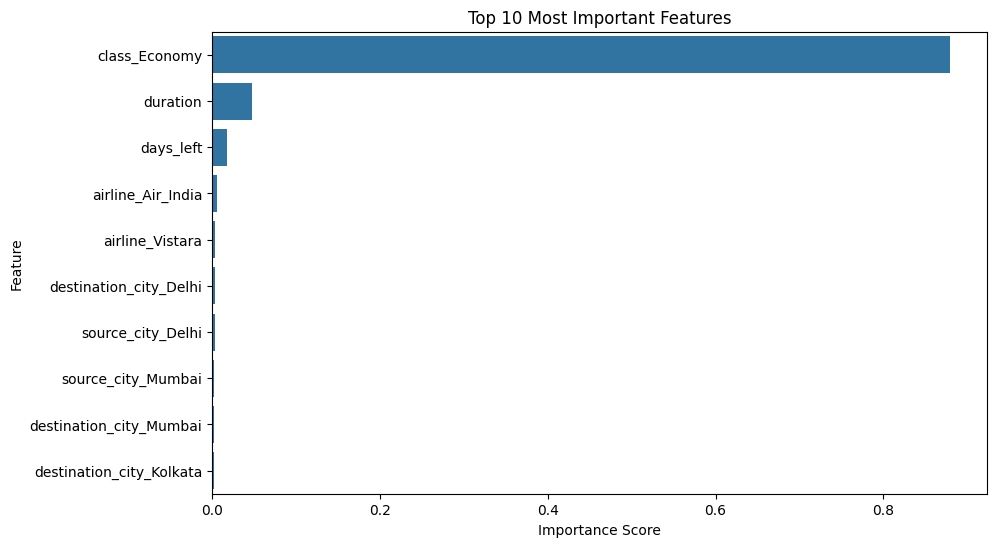

In [49]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Insight

The Random Forest model identified **travel class** as the most influential feature, with an importance score of **0.8796**. This indicates that whether a passenger travels in Economy or Business class has the greatest impact on ticket price. Flight duration and days left before departure also contribute to the prediction, while airline and city-related features have comparatively smaller effects.contribute to the prediction but have relatively low importance compared to travel class.

## Additional Analysis

Since **travel class** dominates the feature importance scores, the remaining features are difficult to compare visually. The following graph excludes **travel class** to better highlight the relative importance of the other predictors.

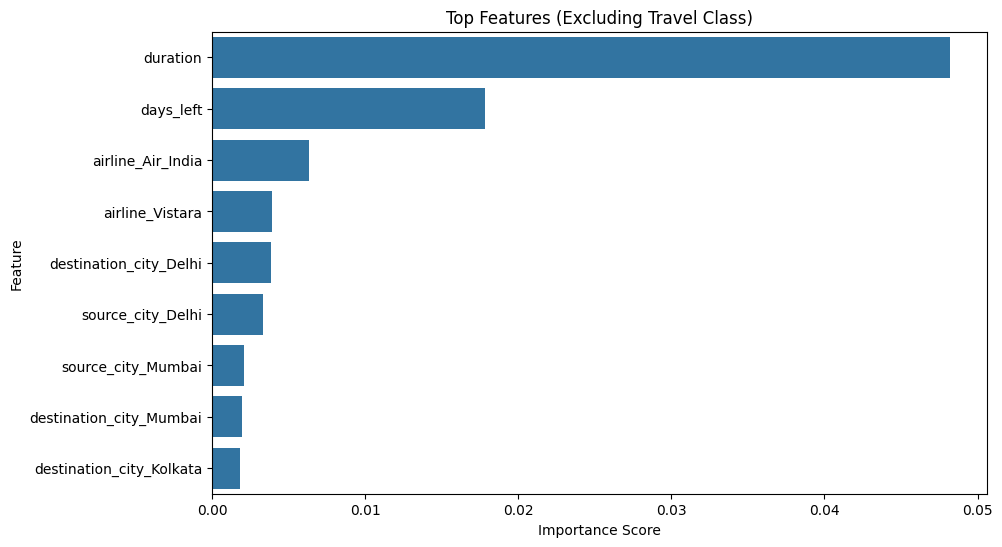

In [50]:
feature_importance_no_class = feature_importance[
    feature_importance["Feature"] != "class_Economy"
]

top9 = feature_importance_no_class.head(9)

plt.figure(figsize=(10,6))
sns.barplot(data=top9, x="Importance", y="Feature")

plt.title("Top Features (Excluding Travel Class)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### Observation

After excluding **travel class**, **flight duration** becomes the most influential remaining feature, followed by **days left before departure**. Airline and source/destination city features have smaller importance scores but still contribute to the model's predictions. This provides a clearer view of how the secondary features influence flight ticket prices.

In [51]:
import joblib

In [52]:
joblib.dump(rf, "flight_price_model.pkl")

['flight_price_model.pkl']

In [53]:
loaded_model = joblib.load("flight_price_model.pkl")

loaded_model

RandomForestRegressor(n_jobs=-1, random_state=42)

In [54]:
loaded_prediction = loaded_model.predict(X_test)

print("Loaded Model R²:",
      round(r2_score(y_test, loaded_prediction),4))

Loaded Model R²: 0.9889


### Model Saving

The best-performing model, Random Forest Regressor, was saved using the joblib library. Saving the trained model enables it to be reused for future predictions without retraining, improving efficiency and supporting future deployment in machine learning applications.

## Summary

This project focused on predicting airline ticket prices using machine learning techniques. The dataset was cleaned and explored through univariate and bivariate analysis to understand feature distributions and relationships. Feature engineering and one-hot encoding were applied to prepare the data for model training. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were trained and evaluated using R² Score, MAE, and RMSE. Among them, the Random Forest Regressor delivered the best performance with an R² Score of 0.9889, making it the most accurate model for predicting flight ticket prices. Finally, the trained model was saved using the joblib library for future use.

## Key Insights


*   The Random Forest Regressor outperformed the other models, providing the highest prediction accuracy.

*   Travel class, flight duration, and days left before departure were the most influential features affecting ticket prices..

*   The model achieved an R² Score of 0.9889, indicating excellent predictive
performance and making it a reliable model for flight ticket price estimation.